<a href="https://colab.research.google.com/github/Naveed101633/Retrieval-Augmented-Generation-RAG-Learning-Lab/blob/main/03-Retrieval_with_Database/RAG_Chunking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Production RAG System — Chunking Deep Dive
> **Stack:** ChromaDB 0.5.x · Sentence-Transformers · Google Gemini · Python 3.12  
> **Conflict-free:** Tested against Colab's pre-installed numpy 2.x environment

### Architecture
```
Raw Text ──► ChunkingEngine ──► EmbeddingEngine ──► ChromaDB
                                                        │
                    Question ──────────────────► Retriever
                                                        │
                                               GenerationEngine (Gemini)
                                                        │
                                               Grounded Answer ✓
```

## CELL 1 — Install (run once, then restart runtime)

**Root cause of the `np.float_` error:** Colab ships numpy 2.x but old ChromaDB (< 0.5.0) used `np.float_` which was removed in numpy 2.0.  
**Fix:** Use `chromadb >= 0.5.0` which is numpy-2.0 compatible. Do NOT downgrade numpy.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — INSTALL  (run once → Runtime > Restart session → continue from Cell 2)
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY these exact versions?
#   chromadb >= 0.5.0   → numpy-2.0 compatible (removed np.float_ dependency)
#   sentence-transformers >= 3.0  → works with torch 2.x + transformers 4.4x
#   google-generativeai >= 0.8    → stable Gemini 1.5 Flash support
#   We do NOT touch numpy — Colab's pre-installed numpy 2.x is fine with these.
#

import subprocess, sys

PACKAGES = [
    # Vector DB — must be >= 0.5.0 for numpy 2.x compat
    "chromadb>=0.5.0,<0.6.0",
    # Embeddings
    "sentence-transformers>=3.0.0",
    # LLM
    "google-generativeai>=0.8.0",
    # Utilities
    "nltk>=3.8.0",
    "tqdm>=4.66.0",
    "rich>=13.7.0",
    "tiktoken>=0.7.0",
]

print("Installing packages...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + PACKAGES,
    capture_output=True, text=True
)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
else:
    print("✅ All packages installed successfully")
    print("\n⚠️  NOW: Runtime → Restart session → then run from Cell 2 onwards")

Installing packages...
✅ All packages installed successfully

⚠️  NOW: Runtime → Restart session → then run from Cell 2 onwards


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — VERIFY IMPORTS  (run after restarting runtime)
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import chromadb
import sentence_transformers
import google.generativeai as genai
import torch
import nltk
from rich.console import Console

console = Console()

console.print("[bold green]✅ All imports successful[/bold green]")
console.print(f"  numpy                : [cyan]{np.__version__}[/cyan]")
console.print(f"  chromadb             : [cyan]{chromadb.__version__}[/cyan]")
console.print(f"  sentence-transformers: [cyan]{sentence_transformers.__version__}[/cyan]")
console.print(f"  torch                : [cyan]{torch.__version__}[/cyan]")
console.print(f"  CUDA available       : [cyan]{torch.cuda.is_available()}[/cyan]")
if torch.cuda.is_available():
    console.print(f"  GPU                  : [cyan]{torch.cuda.get_device_name(0)}[/cyan]")

# Verify the np.float_ issue is NOT present in this env
try:
    _ = np.float_
    console.print("  np.float_            : [yellow]exists (old numpy)[/yellow]")
except AttributeError:
    console.print("  np.float_            : [green]removed (numpy 2.x) — chromadb 0.5+ handles this correctly ✓[/green]")

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
console.print("  NLTK punkt           : [cyan]ready[/cyan]")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ All imports successful

numpy                : 2.0.2

chromadb             : 0.5.23

sentence-transformers: 5.3.0

torch                : 2.10.0+cu128

CUDA available       : True

GPU                  : Tesla T4

np.float_            : removed (numpy 2.x) — chromadb 0.5+ handles this correctly ✓

NLTK punkt           : ready

## CELL 3 — Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — CENTRAL CONFIGURATION
# All tuneable parameters live here. Never hardcode values inside functions.
# ═══════════════════════════════════════════════════════════════════════════════
import os
import torch
from dataclasses import dataclass, field
from typing import Dict, List

@dataclass
class RAGConfig:
    # ── Embedding ──────────────────────────────────────────────────────────────
    embedding_model    : str   = "sentence-transformers/all-MiniLM-L6-v2"
    embedding_device   : str   = "cuda" if torch.cuda.is_available() else "cpu"
    embedding_batch_size: int  = 64

    # ── ChromaDB ──────────────────────────────────────────────────────────────
    chroma_persist_dir : str  = "/content/chroma_rag_db"
    collection_name    : str  = "rag_chunking_lab"

    # ── Chunking ──────────────────────────────────────────────────────────────
    overlap_fraction   : float = 0.20
    min_chunk_words    : int   = 25
    max_chunk_words    : int   = 400

    # ── Retrieval ─────────────────────────────────────────────────────────────
    retrieval_top_k    : int   = 5
    mmr_lambda         : float = 0.5

    # ── Generation ────────────────────────────────────────────────────────────
    gemini_model       : str   = "gemini-2.5-flash"
    gen_temperature    : float = 0.2
    gen_max_tokens     : int   = 1024

    # ── Data ──────────────────────────────────────────────────────────────────
    data_urls: Dict[str, str] = field(default_factory=lambda: {
    "git_what_is_git": "https://raw.githubusercontent.com/progit/progit2/main/book/01-introduction/sections/what-is-git.asc",

    "git_getting_started": "https://raw.githubusercontent.com/progit/progit2/main/ch01-getting-started.asc",

    "git_git_basics": "https://raw.githubusercontent.com/progit/progit2/main/ch02-git-basics-chapter.asc",

    "git_branching": "https://raw.githubusercontent.com/progit/progit2/main/ch03-git-branching.asc",
})

cfg = RAGConfig()
console.print(f"[bold green]✅ Config loaded[/bold green]")
console.print(f"   device        : [cyan]{cfg.embedding_device}[/cyan]")
console.print(f"   gemini model  : [cyan]{cfg.gemini_model}[/cyan]")
console.print(f"   chroma path   : [cyan]{cfg.chroma_persist_dir}[/cyan]")

✅ Config loaded

device        : cuda

gemini model  : gemini-2.5-flash

chroma path   : /content/chroma_rag_db

## CELL 4 — Gemini API Key

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — GEMINI API KEY
# Best practice: Colab Secrets (🔑 icon in left panel → add GEMINI_API_KEY)
# ═══════════════════════════════════════════════════════════════════════════════
import google.generativeai as genai

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('API_KEY')
    console.print("[green]✅ Loaded GEMINI_API_KEY from Colab Secrets[/green]")
except Exception:
    import getpass
    GEMINI_API_KEY = getpass.getpass("Paste your Gemini API key (https://aistudio.google.com/app/apikey): ")

genai.configure(api_key=GEMINI_API_KEY)

# Quick connectivity test
try:
    test_model = genai.GenerativeModel(cfg.gemini_model)
    test_resp  = test_model.generate_content("Reply with only the word: CONNECTED")
    console.print(f"[green]✅ Gemini API working — response: {test_resp.text.strip()}[/green]")
except Exception as e:
    console.print(f"[red]❌ Gemini API error: {e}[/red]")
    console.print("   Get a free key at: https://aistudio.google.com/app/apikey")

✅ Loaded GEMINI_API_KEY from Colab Secrets

✅ Gemini API working — response: CONNECTED

## CELL 5 — Document Loader

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — DOCUMENT LOADER
# ═══════════════════════════════════════════════════════════════════════════════
import re
import requests
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Optional

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger("rag")


@dataclass
class Document:
    """Typed container for a loaded document."""
    doc_id   : str
    text     : str
    metadata : Dict[str, str] = field(default_factory=dict)

    @property
    def word_count(self) -> int:
        return len(self.text.split())

    def __repr__(self) -> str:
        return f"Document(id={self.doc_id!r}, words={self.word_count})"


class DocumentLoader:
    """Fetch + clean documents from URLs or raw strings."""

    # Strip asciidoc structural markers
    _STRIP = re.compile(r'^(={1,6}\s+|\[\[.*?\]\]|include::.*?\[\])', re.MULTILINE)

    @classmethod
    def from_url(cls, doc_id: str, url: str,
                 extra_meta: Optional[Dict] = None) -> Document:
        resp = requests.get(url, timeout=20)
        resp.raise_for_status()
        text = cls._clean(resp.text)
        meta = {"doc_id": doc_id, "source": url, **( extra_meta or {})}
        console.print(f"  Loaded [cyan]{doc_id}[/cyan] — {len(text.split()):,} words")
        return Document(doc_id=doc_id, text=text, metadata=meta)

    @classmethod
    def from_string(cls, doc_id: str, text: str,
                    meta: Optional[Dict] = None) -> Document:
        return Document(doc_id=doc_id, text=cls._clean(text),
                        metadata=meta or {"doc_id": doc_id, "source": "inline"})

    @staticmethod
    def _clean(text: str) -> str:
        text = DocumentLoader._STRIP.sub('', text)
        text = re.sub(r'\n{3,}', '\n\n', text)   # max 2 blank lines
        text = re.sub(r'[ \t]+', ' ', text)        # collapse spaces
        return text.strip()


# Load all documents
console.print("[bold]Loading documents...[/bold]")
documents: List[Document] = []
for doc_id, url in cfg.data_urls.items():
    doc = DocumentLoader.from_url(doc_id, url, extra_meta={"book": "Pro Git"})
    documents.append(doc)

console.print(f"[bold green]\n✅ {len(documents)} documents loaded[/bold green]")

Loading documents...

Loaded git_what_is_git — 1,396 words

Loaded git_getting_started — 129 words

Loaded git_git_basics — 160 words

Loaded git_branching — 223 words

✅ 4 documents loaded

## CELL 6 — Chunking Engine (5 strategies)

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — CHUNKING ENGINE
# 5 strategies: fixed | overlap | paragraph | sentence_window | mixed
# ═══════════════════════════════════════════════════════════════════════════════
import hashlib
import nltk
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class Chunk:
    """A single text chunk ready for embedding.
    chunk_id is a deterministic content-hash → idempotent upserts.
    """
    text     : str
    metadata : Dict
    chunk_id : str = field(init=False)

    def __post_init__(self):
        fp = self.text + str(sorted(self.metadata.items()))
        self.chunk_id = hashlib.md5(fp.encode()).hexdigest()

    @property
    def word_count(self) -> int:
        return len(self.text.split())


class ChunkingEngine:
    """
    Production chunking — all strategies return List[Chunk] with full metadata.

    Strategy guide
    --------------
    fixed_size          – exact word windows, no overlap
    fixed_size_overlap  – word windows + configurable overlap
    paragraph           – split on blank lines, merge short fragments
    sentence_window     – NLTK sentences grouped into windows
    mixed (recommended) – paragraph-first, then enforce min/max word guards
    """

    def __init__(self, config: RAGConfig):
        self.cfg = config

    # ── Private helpers ────────────────────────────────────────────────────────
    def _chunk(self, text: str, doc: Document, strategy: str, idx: int) -> Optional[Chunk]:
        text = text.strip()
        if len(text.split()) < 3:
            return None
        meta = {
            **doc.metadata,
            "strategy"   : strategy,
            "chunk_index": str(idx),
            "word_count" : str(len(text.split())),
        }
        return Chunk(text=text, metadata=meta)

    # ── Strategy 1: Fixed size ─────────────────────────────────────────────────
    def fixed_size(self, doc: Document, chunk_size: int) -> List[Chunk]:
        """Non-overlapping word windows. Fast and predictable."""
        words  = doc.text.split()
        result = []
        for i, start in enumerate(range(0, len(words), chunk_size)):
            c = self._chunk(" ".join(words[start: start + chunk_size]),
                            doc, f"fixed_{chunk_size}w", i)
            if c:
                result.append(c)
        return result

    # ── Strategy 2: Fixed size with overlap ───────────────────────────────────
    def fixed_size_overlap(self, doc: Document, chunk_size: int,
                           overlap_fraction: Optional[float] = None) -> List[Chunk]:
        """Overlapping word windows — reduces boundary miss rate."""
        frac    = overlap_fraction or self.cfg.overlap_fraction
        overlap = max(1, int(chunk_size * frac))
        step    = chunk_size - overlap
        words   = doc.text.split()
        result, idx = [], 0
        for start in range(0, len(words), step):
            c = self._chunk(" ".join(words[start: start + chunk_size]),
                            doc, f"fixed_{chunk_size}w_ov{int(frac*100)}pct", idx)
            if c:
                result.append(c)
                idx += 1
        return result

    # ── Strategy 3: Paragraph ─────────────────────────────────────────────────
    def paragraph(self, doc: Document,
                  min_words: Optional[int] = None) -> List[Chunk]:
        """Split on blank lines. Short paragraphs merge into the next one
        so headings stay attached to their body text."""
        min_w  = min_words or self.cfg.min_chunk_words
        raw    = doc.text.split("\n\n")
        buf    = ""
        merged = []
        for para in raw:
            candidate = (buf + " " + para).strip()
            if len(candidate.split()) < min_w:
                buf = candidate
            else:
                merged.append(candidate)
                buf = ""
        if buf.strip():
            merged.append(buf.strip())
        return [c for i, p in enumerate(merged)
                if (c := self._chunk(p, doc, "paragraph", i))]

    # ── Strategy 4: Sentence window ───────────────────────────────────────────
    def sentence_window(self, doc: Document, window: int = 3) -> List[Chunk]:
        """Group NLTK sentences into windows with 1-sentence overlap.
        Respects natural language boundaries better than word windows."""
        sents  = nltk.sent_tokenize(doc.text)
        step   = max(1, window - 1)
        result, idx = [], 0
        for start in range(0, len(sents), step):
            c = self._chunk(" ".join(sents[start: start + window]),
                            doc, f"sentence_win{window}", idx)
            if c:
                result.append(c)
                idx += 1
        return result

    # ── Strategy 5: Mixed (RECOMMENDED for production) ────────────────────────
    def mixed(self, doc: Document,
              min_words: Optional[int] = None,
              max_words: Optional[int] = None) -> List[Chunk]:
        """
        Paragraph split first (semantic boundaries), then enforce guards:
          too small  → already merged in paragraph()
          too large  → sub-split at sentence boundaries
        Best balance of precision and context for production RAG.
        """
        min_w = min_words or self.cfg.min_chunk_words
        max_w = max_words or self.cfg.max_chunk_words
        para_chunks = self.paragraph(doc, min_words=min_w)

        final, idx = [], 0
        for pc in para_chunks:
            if pc.word_count <= max_w:
                c = self._chunk(pc.text, doc, "mixed", idx)
                if c:
                    final.append(c)
                    idx += 1
            else:
                # Sub-split oversized paragraph at sentence boundaries
                sents, buf = nltk.sent_tokenize(pc.text), ""
                for sent in sents:
                    candidate = (buf + " " + sent).strip()
                    if len(candidate.split()) > max_w:
                        if buf:
                            c = self._chunk(buf, doc, "mixed", idx)
                            if c:
                                final.append(c)
                                idx += 1
                        buf = sent
                    else:
                        buf = candidate
                if buf:
                    c = self._chunk(buf, doc, "mixed", idx)
                    if c:
                        final.append(c)
                        idx += 1
        return final


chunker = ChunkingEngine(cfg)

# ── Preview all strategies on sample doc ──────────────────────────────────────
STRATEGIES = {
    "fixed_25w"         : lambda d: chunker.fixed_size(d, 25),
    "fixed_100w"        : lambda d: chunker.fixed_size(d, 100),
    "fixed_25w_ov20pct" : lambda d: chunker.fixed_size_overlap(d, 25),
    "fixed_100w_ov20pct": lambda d: chunker.fixed_size_overlap(d, 100),
    "paragraph"         : lambda d: chunker.paragraph(d),
    "sentence_window"   : lambda d: chunker.sentence_window(d, window=3),
    "mixed"             : lambda d: chunker.mixed(d),
}

import pandas as pd
sample = documents[0]
rows   = []
for name, fn in STRATEGIES.items():
    wcs  = [c.word_count for c in fn(sample)]
    rows.append({"Strategy": name, "# Chunks": len(wcs),
                 "Min": min(wcs), "Mean": round(sum(wcs)/len(wcs),1),
                 "Max": max(wcs)})

df = pd.DataFrame(rows).set_index("Strategy")
console.print(f"[bold green]\n✅ ChunkingEngine ready — 5 strategies[/bold green]")
print(df.to_string())

✅ ChunkingEngine ready — 5 strategies

                    # Chunks  Min  Mean  Max
Strategy                                    
fixed_25w                 56   21  24.9   25
fixed_100w                14   96  99.7  100
fixed_25w_ov20pct         70   16  24.9   25
fixed_100w_ov20pct        18   36  96.4  100
paragraph                 20   36  69.8  134
sentence_window           32   17  66.4  110
mixed                     20   36  69.8  134


## CELL 7 — Visualise Chunk Distributions

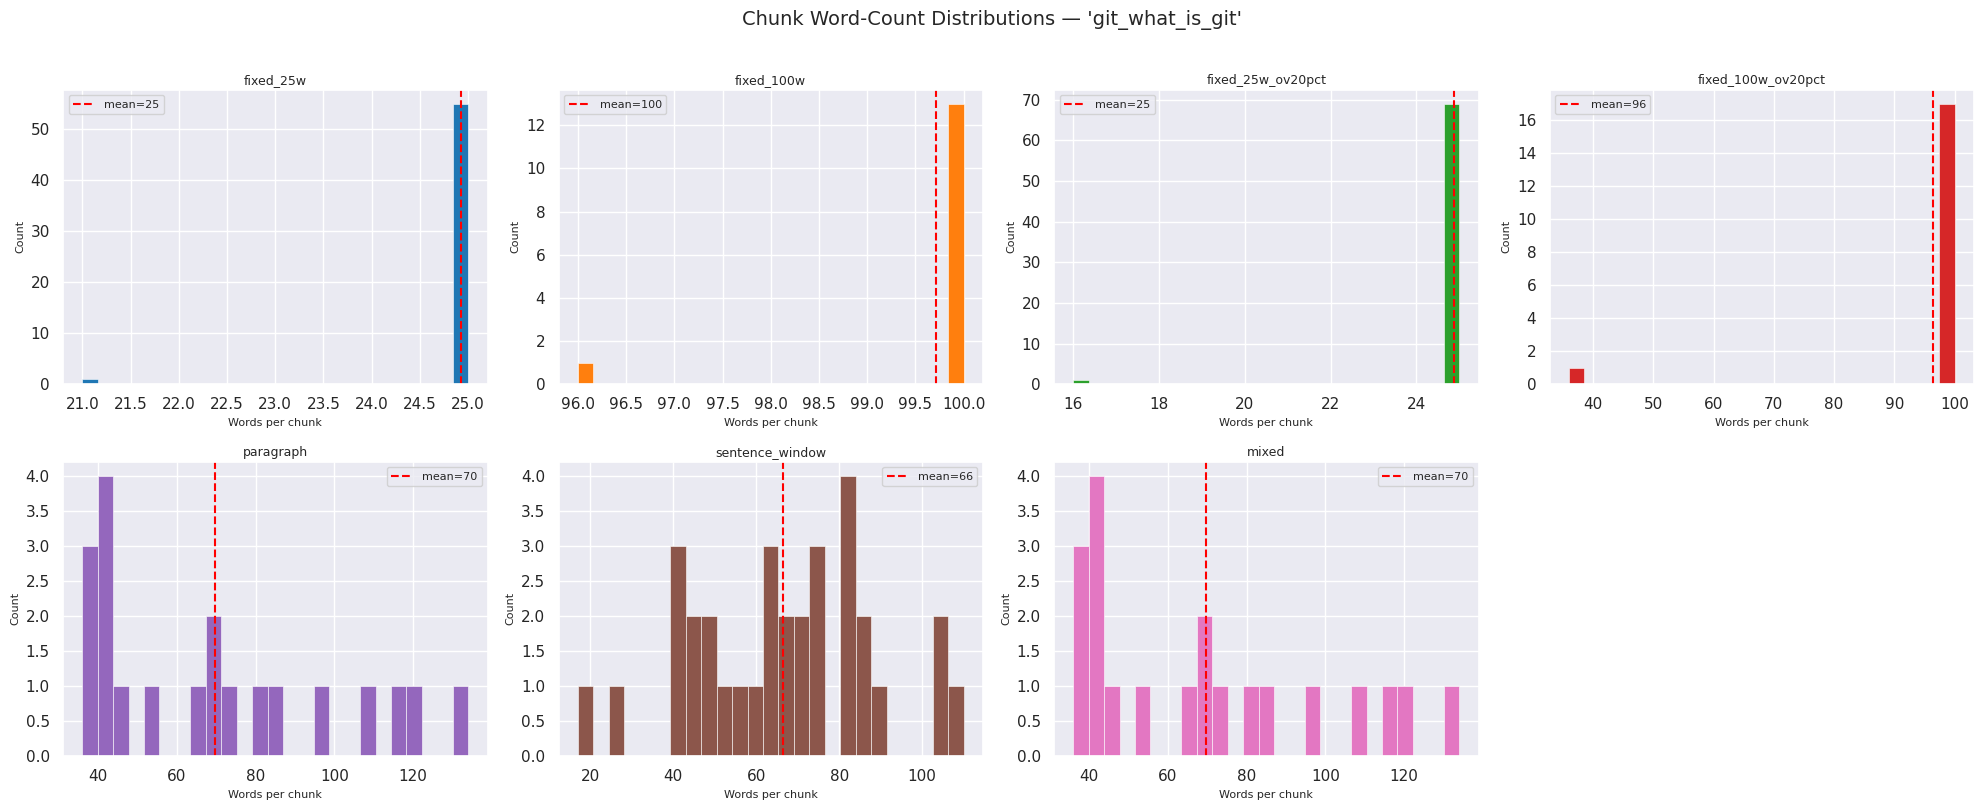

✅ Saved → /content/chunk_distributions.png

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — VISUALISE CHUNK WORD-COUNT DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
palette = sns.color_palette("tab10", len(STRATEGIES))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f"Chunk Word-Count Distributions — '{sample.doc_id}'",
             fontsize=14, y=1.01)
axes = axes.flatten()

for ax, (color, (name, fn)) in zip(axes, zip(palette, STRATEGIES.items())):
    wcs  = [c.word_count for c in fn(sample)]
    mean = sum(wcs) / len(wcs)
    ax.hist(wcs, bins=25, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(mean, color="red", linestyle="--", linewidth=1.5,
               label=f"mean={mean:.0f}")
    ax.set_title(name, fontsize=9, pad=4)
    ax.set_xlabel("Words per chunk", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=8)

for ax in axes[len(STRATEGIES):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("/content/chunk_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
console.print("[green]✅ Saved → /content/chunk_distributions.png[/green]")

## CELL 8 — Embedding Engine

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — EMBEDDING ENGINE
# Batched sentence-transformers, L2-normalised, GPU-aware
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
from sentence_transformers import SentenceTransformer
from typing import List


class EmbeddingEngine:
    """
    Wraps sentence-transformers with:
    - Batched GPU inference
    - L2-normalised output (unit vectors → cosine sim == dot product)
    - Progress bar for large corpora
    """

    def __init__(self, model_name: str, device: str, batch_size: int):
        console.print(f"Loading embedding model [cyan]{model_name}[/cyan] on [cyan]{device}[/cyan] ...")
        self.model      = SentenceTransformer(model_name, device=device)
        self.batch_size = batch_size
        self.dim        = self.model.get_sentence_embedding_dimension()
        console.print(f"[green]✅ Embedding model ready | dim={self.dim}[/green]")

    def embed(self, texts: List[str], show_progress: bool = True) -> np.ndarray:
        """Encode texts → (N, dim) float32 array, L2-normalised."""
        return self.model.encode(
            texts,
            batch_size=self.batch_size,
            show_progress_bar=show_progress,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype(np.float32)

    def embed_query(self, query: str) -> np.ndarray:
        """Single query embed — no progress bar."""
        return self.embed([query], show_progress=False)[0]


embedder = EmbeddingEngine(
    model_name  = cfg.embedding_model,
    device      = cfg.embedding_device,
    batch_size  = cfg.embedding_batch_size,
)

# Quick sanity check
test_vec = embedder.embed_query("hello world")
console.print(f"   Test embed shape  : [cyan]{test_vec.shape}[/cyan]")
console.print(f"   Test embed norm   : [cyan]{np.linalg.norm(test_vec):.4f}[/cyan] (should be ~1.0)")

Loading embedding model sentence-transformers/all-MiniLM-L6-v2 on cuda ...

✅ Embedding model ready | dim=384

Test embed shape  : (384,)

Test embed norm   : 1.0000 (should be ~1.0)

## CELL 9 — Vector Store (ChromaDB)

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — VECTOR STORE (ChromaDB)
# Persistent, metadata-filtered, idempotent upserts, MMR retrieval
# ═══════════════════════════════════════════════════════════════════════════════
import chromadb
from chromadb.config import Settings
from typing import Dict, List, Optional
import numpy as np
import os


class VectorStore:
    """
    ChromaDB-backed store with:
    - Persistent disk storage (survives Colab session)
    - Per-strategy filtering via metadata
    - Idempotent upsert using deterministic chunk IDs
    - Built-in MMR reranking
    """

    def __init__(self, persist_dir: str, collection_name: str):
        os.makedirs(persist_dir, exist_ok=True)
        self._client = chromadb.PersistentClient(
            path=persist_dir,
            settings=Settings(anonymized_telemetry=False),
        )
        self._col = self._client.get_or_create_collection(
            name=collection_name,
            metadata={"hnsw:space": "cosine"},
        )
        console.print(f"[green]✅ VectorStore ready[/green] | collection=[cyan]{collection_name}[/cyan] | records={self._col.count()}")

    # ── Ingestion ──────────────────────────────────────────────────────────────
    def upsert(self, chunks: List[Chunk], embedder: EmbeddingEngine,
               batch_size: int = 128) -> int:
        """Embed and upsert in batches. Safe to call multiple times (idempotent)."""
        total = 0
        for start in range(0, len(chunks), batch_size):
            batch  = chunks[start: start + batch_size]
            texts  = [c.text for c in batch]
            ids    = [c.chunk_id for c in batch]
            metas  = [c.metadata for c in batch]
            vecs   = embedder.embed(texts, show_progress=False).tolist()
            self._col.upsert(ids=ids, embeddings=vecs,
                             documents=texts, metadatas=metas)
            total += len(batch)
        return total

    # ── Retrieval ──────────────────────────────────────────────────────────────
    def query(self, query_vec: np.ndarray, top_k: int = 5,
              where: Optional[Dict] = None) -> List[Dict]:
        """Standard nearest-neighbour search."""
        n = min(top_k, max(1, self._col.count()))
        r = self._col.query(
            query_embeddings=[query_vec.tolist()],
            n_results=n, where=where,
            include=["documents", "metadatas", "distances", "embeddings"],
        )
        return [
            {
                "text"     : r["documents"][0][i],
                "metadata" : r["metadatas"][0][i],
                "score"    : round(1 - r["distances"][0][i], 4),
                "embedding": np.array(r["embeddings"][0][i], dtype=np.float32),
            }
            for i in range(len(r["documents"][0]))
        ]

    def mmr_query(self, query_vec: np.ndarray, top_k: int = 5,
                  fetch_k: int = 20, lambda_mult: float = 0.5,
                  where: Optional[Dict] = None) -> List[Dict]:
        """
        Maximal Marginal Relevance retrieval.
        Balances relevance (lambda_mult → 1.0) vs diversity (lambda_mult → 0.0).
        """
        candidates = self.query(query_vec, top_k=fetch_k, where=where)
        if not candidates:
            return []

        selected, sel_vecs = [], []
        remaining = list(range(len(candidates)))

        while len(selected) < top_k and remaining:
            if not selected:
                best = max(remaining, key=lambda i: candidates[i]["score"])
            else:
                def mmr_score(i):
                    rel = candidates[i]["score"]
                    red = max(float(np.dot(candidates[i]["embedding"], sv))
                              for sv in sel_vecs)
                    return lambda_mult * rel - (1 - lambda_mult) * red
                best = max(remaining, key=mmr_score)

            selected.append(candidates[best])
            sel_vecs.append(candidates[best]["embedding"])
            remaining.remove(best)

        # Strip raw embedding from output
        for r in selected:
            r.pop("embedding", None)
        return selected

    @property
    def count(self) -> int:
        return self._col.count()


vector_store = VectorStore(cfg.chroma_persist_dir, cfg.collection_name)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


✅ VectorStore ready | collection=rag_chunking_lab | records=0

## CELL 10 — Ingest all chunks into ChromaDB

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — BUILD CORPUS & INGEST INTO CHROMADB
# Idempotent — safe to re-run, same chunk IDs just get upserted again
# ═══════════════════════════════════════════════════════════════════════════════
from tqdm.auto import tqdm

all_chunks: Dict[str, List[Chunk]] = {}

console.print("[bold]Chunking all documents...[/bold]")
for strat_name, fn in STRATEGIES.items():
    strat_chunks = []
    for doc in documents:
        strat_chunks.extend(fn(doc))
    all_chunks[strat_name] = strat_chunks
    console.print(f"  {strat_name:25s}: [cyan]{len(strat_chunks):5d}[/cyan] chunks")

total = sum(len(v) for v in all_chunks.values())
console.print(f"\nTotal chunks across all strategies: [cyan]{total:,}[/cyan]")

console.print("\n[bold]Embedding & upserting into ChromaDB...[/bold]")
for strat_name, chunks in tqdm(all_chunks.items(), desc="Strategies"):
    n = vector_store.upsert(chunks, embedder)
    console.print(f"  {strat_name:25s}: upserted [cyan]{n}[/cyan] chunks")

console.print(f"\n[bold green]✅ ChromaDB loaded | total records = {vector_store.count:,}[/bold green]")

Chunking all documents...

fixed_25w                :    78 chunks

fixed_100w               :    21 chunks

fixed_25w_ov20pct        :    97 chunks

fixed_100w_ov20pct       :    25 chunks

...

fixed_100w_ov20pct       : upserted 25 chunks

paragraph                : upserted 27 chunks

sentence_window          : upserted 44 chunks

mixed                    : upserted 27 chunks

✅ ChromaDB loaded | total records = 319

## CELL 11 — Retriever

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════
from rich.table import Table


class Retriever:
    """High-level retrieval API with strategy filtering and pretty printing."""

    def __init__(self, store: VectorStore, embedder: EmbeddingEngine, config: RAGConfig):
        self.store   = store
        self.embedder = embedder
        self.cfg     = config

    def retrieve(
        self,
        query    : str,
        strategy : Optional[str] = None,
        top_k    : Optional[int] = None,
        use_mmr  : bool = False,
    ) -> List[Dict]:
        k     = top_k or self.cfg.retrieval_top_k
        q_vec = self.embedder.embed_query(query)
        where = {"strategy": {"$eq": strategy}} if strategy else None
        if use_mmr:
            return self.store.mmr_query(q_vec, top_k=k, fetch_k=k*4,
                                        lambda_mult=self.cfg.mmr_lambda, where=where)
        return self.store.query(q_vec, top_k=k, where=where)

    def compare_all_strategies(
        self, query: str, top_k: int = 2
    ) -> Dict[str, List[Dict]]:
        return {s: self.retrieve(query, strategy=s, top_k=top_k)
                for s in STRATEGIES}

    def print_comparison(self, query: str, results: Dict[str, List[Dict]]) -> None:
        console.rule(f"[bold yellow]Query: {query!r}")
        for strat, hits in results.items():
            tbl = Table(title=f"Strategy: {strat}", show_lines=True,
                        title_style="bold cyan")
            tbl.add_column("#",     style="dim",     width=3)
            tbl.add_column("Score", style="green",   width=7)
            tbl.add_column("Wds",   style="blue",    width=5)
            tbl.add_column("Doc",   style="magenta", width=16)
            tbl.add_column("Text",  ratio=1)
            for i, h in enumerate(hits, 1):
                tbl.add_row(
                    str(i),
                    str(h["score"]),
                    h["metadata"].get("word_count", "?"),
                    h["metadata"].get("doc_id", "?")[:16],
                    h["text"][:250].replace("\n", " ") + "…",
                )
            console.print(tbl)


retriever = Retriever(vector_store, embedder, cfg)
console.print("[bold green]✅ Retriever ready[/bold green]")

# Test retrieval
results = retriever.compare_all_strategies("What is the history of Git?", top_k=2)
retriever.print_comparison("What is the history of Git?", results)

✅ Retriever ready

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


────────────────────────────────────── Query: 'What is the history of Git?' ───────────────────────────────────────

                                                Strategy: fixed_25w                                                
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.7268  │ 25    │ git_getting_star │ You should have a basic understanding of what Git is and how it's    │
│     │         │       │                  │ different from any centralized version control systems you may have  │
│     │         │       │                  │ been using…                                                          │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.6962  │ 25    │ git_what_is_git  │ What is Git? So, what is Git in a nutshell? This is an important     │
│     │         │       │                  │ section to absorb, because if you understand what Git is and…        │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

                                               Strategy: fixed_100w                                                
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.5785  │ 100   │ git_what_is_git  │ What is Git? So, what is Git in a nutshell? This is an important     │
│     │         │       │                  │ section to absorb, because if you understand what Git is and the     │
│     │         │       │                  │ fundamentals of how it works, then using Git effectively will        │
│     │         │       │                  │ probably be much easier for you. As you learn Git, try to …          │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.5711  │ 29    │ git_getting_star │ previously. You should also now have a working version of Git on     │
│     │         │       │                  │ your system that's set up with your personal identity. It's now time │
│     │         │       │                  │ to learn some Git basics.…                                           │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

                                            Strategy: fixed_25w_ov20pct                                            
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.7308  │ 25    │ git_getting_star │ understanding of what Git is and how it's different from any         │
│     │         │       │                  │ centralized version control systems you may have been using          │
│     │         │       │                  │ previously. You should also now…                                     │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.6962  │ 25    │ git_what_is_git  │ What is Git? So, what is Git in a nutshell? This is an important     │
│     │         │       │                  │ section to absorb, because if you understand what Git is and…        │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

                                           Strategy: fixed_100w_ov20pct                                            
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.595   │ 36    │ git_what_is_git  │ since it was checked out but has not been staged, it is _modified_.  │
│     │         │       │                  │ In <<ch02-git-basics-chapter#ch02-git-basics-chapter>>, you'll learn │
│     │         │       │                  │ more about these states and how you can either take advantage of     │
│     │         │       │                  │ them or skip the staged part entirely.…                              │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.5948  │ 49    │ git_getting_star │ understanding of what Git is and how it's different from any         │
│     │         │       │                  │ centralized version control systems you may have been using          │
│     │         │       │                  │ previously. You should also now have a working version of Git on     │
│     │         │       │                  │ your system that's set up with your personal identity. It's now …    │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

                                                Strategy: paragraph                                                
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.5955  │ 55    │ git_getting_star │ Summary You should have a basic understanding of what Git is and how │
│     │         │       │                  │ it's different from any centralized version control systems you may  │
│     │         │       │                  │ have been using previously. You should also now have a working       │
│     │         │       │                  │ version of Git on your system that's set up with y…                  │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.5819  │ 48    │ git_git_basics   │ Summary At this point, you can do all the basic local Git operations │
│     │         │       │                  │ -- creating or cloning a repository, making changes, staging and     │
│     │         │       │                  │ committing those changes, and viewing the history of all the changes │
│     │         │       │                  │ the repository has been through. Next, we'll co…                     │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

             Strategy: sentence_window             
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━┩
└─────┴─────────┴───────┴──────────────────┴──────┘

                                                  Strategy: mixed                                                  
┏━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #   ┃ Score   ┃ Wds   ┃ Doc              ┃ Text                                                                 ┃
┡━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1   │ 0.5955  │ 55    │ git_getting_star │ Summary You should have a basic understanding of what Git is and how │
│     │         │       │                  │ it's different from any centralized version control systems you may  │
│     │         │       │                  │ have been using previously. You should also now have a working       │
│     │         │       │                  │ version of Git on your system that's set up with y…                  │
├─────┼─────────┼───────┼──────────────────┼──────────────────────────────────────────────────────────────────────┤
│ 2   │ 0.5819  │ 48    │ git_git_basics   │ Summary At this point, you can do all the basic local Git operations │
│     │         │       │                  │ -- creating or cloning a repository, making changes, staging and     │
│     │         │       │                  │ committing those changes, and viewing the history of all the changes │
│     │         │       │                  │ the repository has been through. Next, we'll co…                     │
└─────┴─────────┴───────┴──────────────────┴──────────────────────────────────────────────────────────────────────┘

## CELL 12 — Generation Engine (Gemini)

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — GENERATION ENGINE (GEMINI)
# Structured RAG prompt + citations + exponential back-off
# ═══════════════════════════════════════════════════════════════════════════════
import time
import google.generativeai as genai


class GenerationEngine:
    """
    Gemini-powered generator with:
    - Structured RAG prompt (question + numbered context chunks)
    - Citation instructions ([1], [2], ...)
    - Exponential back-off on API errors
    - Token usage tracking
    """

    _PROMPT = """You are a precise technical assistant.
Answer the QUESTION using ONLY the CONTEXT below.
If the context lacks sufficient information, say so explicitly — never fabricate.

## QUESTION
{question}

## CONTEXT (retrieved chunks)
{context}

## INSTRUCTIONS
- Answer in clear bullet points.
- After each fact, cite the chunk number in brackets, e.g. [1], [3].
- End with a one-sentence summary.

## ANSWER"""

    def __init__(self, model_name: str, temperature: float, max_tokens: int):
        self.model      = genai.GenerativeModel(model_name)
        self.gen_config = genai.GenerationConfig(
            temperature=temperature, max_output_tokens=max_tokens)

    def _build_context(self, chunks: List[Dict]) -> str:
        lines = []
        for i, c in enumerate(chunks, 1):
            doc   = c["metadata"].get("doc_id", "?")
            strat = c["metadata"].get("strategy", "?")
            lines.append(f"[{i}] source={doc} strategy={strat}")
            lines.append(c["text"].strip())
            lines.append("")
        return "\n".join(lines)

    def generate(self, question: str, chunks: List[Dict],
                 max_retries: int = 3) -> Dict:
        """Generate a grounded, cited answer from retrieved context."""
        context = self._build_context(chunks)
        prompt  = self._PROMPT.format(question=question, context=context)

        for attempt in range(max_retries):
            try:
                resp = self.model.generate_content(
                    prompt, generation_config=self.gen_config)
                return {
                    "answer"       : resp.text,
                    "input_tokens" : resp.usage_metadata.prompt_token_count,
                    "output_tokens": resp.usage_metadata.candidates_token_count,
                }
            except Exception as exc:
                wait = 2 ** attempt
                console.print(f"[yellow]Gemini attempt {attempt+1} failed: {exc} — retry in {wait}s[/yellow]")
                time.sleep(wait)

        raise RuntimeError(f"Gemini failed after {max_retries} attempts")


generator = GenerationEngine(cfg.gemini_model, cfg.gen_temperature, cfg.gen_max_tokens)
console.print(f"[bold green]✅ GenerationEngine ready | model={cfg.gemini_model}[/bold green]")

✅ GenerationEngine ready | model=gemini-2.5-flash

## CELL 13 — RAG Pipeline (end-to-end)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13 — RAG PIPELINE
# Single .run() entry point: retrieve → generate → return structured result
# ═══════════════════════════════════════════════════════════════════════════════
import time
from rich.panel import Panel
from rich.markdown import Markdown


class RAGPipeline:
    """End-to-end RAG: retrieve + generate with latency + token tracking."""

    def __init__(self, retriever: Retriever,
                 generator: GenerationEngine, config: RAGConfig):
        self.retriever = retriever
        self.generator = generator
        self.cfg       = config

    def run(
        self,
        question : str,
        strategy : Optional[str] = "mixed",
        top_k    : Optional[int] = None,
        use_mmr  : bool = True,
        verbose  : bool = True,
    ) -> Dict:
        """
        Returns dict with: question, strategy, chunks, answer,
                           input_tokens, output_tokens,
                           retrieval_ms, generation_ms
        """
        # Retrieve
        t0 = time.perf_counter()
        chunks = self.retriever.retrieve(
            question, strategy=strategy, top_k=top_k, use_mmr=use_mmr)
        ret_ms = int((time.perf_counter() - t0) * 1000)

        # Generate
        t0 = time.perf_counter()
        gen = self.generator.generate(question, chunks)
        gen_ms = int((time.perf_counter() - t0) * 1000)

        if verbose:
            console.print(
                f"[dim]Retrieve: {len(chunks)} chunks in {ret_ms}ms | "
                f"Generate: {gen['output_tokens']} tokens in {gen_ms}ms[/dim]"
            )
            console.print(Panel(
                Markdown(gen["answer"]),
                title=f"[bold green]Answer[/bold green]  strategy=[cyan]{strategy!r}[/cyan]",
                border_style="green",
            ))

        return {
            "question"      : question,
            "strategy"      : strategy,
            "chunks"        : chunks,
            "answer"        : gen["answer"],
            "input_tokens"  : gen["input_tokens"],
            "output_tokens" : gen["output_tokens"],
            "retrieval_ms"  : ret_ms,
            "generation_ms" : gen_ms,
        }


pipeline = RAGPipeline(retriever, generator, cfg)
console.print("[bold green]✅ RAGPipeline ready[/bold green]")

# ── End-to-end test ───────────────────────────────────────────────────────────
result = pipeline.run(
    question = "What is Git and why was it created?",
    strategy = "mixed",
    top_k    = 5,
    use_mmr  = True,
)

✅ RAGPipeline ready

Retrieve: 5 chunks in 27ms | Generate: 168 tokens in 6330ms

╭─────────────────────────────────────────── Answer  strategy='mixed' ────────────────────────────────────────────╮
│                                                                                                                 │
│  • Git is a version control system (VCS) [1], [3].                                                              │
│  • Its branching model is a "killer feature" that sets it apart in the VCS community [3].                       │
│  • Git's branching operations are incredibly lightweight and nearly instantaneous, allowing for frequent        │
│    branching and merging [3].                                                                                   │
│  • Git uses SHA-1 hashes for checksumming, which are 40-character hexadecimal strings calculated based on file  │
│    or directory contents [2].                                                                                   │
│  • Using Git allows for experimentation without the danger of severely screwing things up [4].                  │
│  • The Git directory stores metadata and the object database for a project, and is copied when a repository is  │
│    cloned [5].                                                                                                  │
│                                                                                                                 │
│ The provided context describes what Git is and some of its features, but it does not explicitly state why Git   │
│ was created.                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## CELL 14 — Benchmark all strategies

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14 — BENCHMARK: all strategies × all query types
# Metric: keyword-hit-rate (lightweight recall proxy)
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

BENCHMARK_QUERIES = [
    {"query": "What is the history and origin of Git?",
     "keywords": ["linus", "torvalds", "linux", "2005", "bitkeeper"],
     "type": "broad"},
    {"query": "How do I add a remote repository with git remote add?",
     "keywords": ["git remote add", "shortname", "url", "origin"],
     "type": "specific"},
    {"query": "What are snapshots in Git versus deltas?",
     "keywords": ["snapshot", "delta", "stream", "filesystem"],
     "type": "conceptual"},
    {"query": "How does Git use SHA-1 checksums for data integrity?",
     "keywords": ["sha-1", "checksum", "hash", "integrity"],
     "type": "technical"},
]

def keyword_hit_rate(chunks: List[Dict], keywords: List[str]) -> float:
    combined = " ".join(c["text"].lower() for c in chunks)
    return sum(kw.lower() in combined for kw in keywords) / len(keywords)

def avg_score(chunks: List[Dict]) -> float:
    return round(sum(c["score"] for c in chunks) / len(chunks), 4) if chunks else 0.0

def avg_wc(chunks: List[Dict]) -> float:
    wcs = [int(c["metadata"].get("word_count", 0)) for c in chunks]
    return round(sum(wcs) / len(wcs), 1) if wcs else 0.0

rows = []
for bq in tqdm(BENCHMARK_QUERIES, desc="Benchmark"):
    for strat in STRATEGIES:
        chunks = retriever.retrieve(bq["query"], strategy=strat, top_k=5)
        rows.append({
            "query"     : bq["query"][:45] + "...",
            "query_type": bq["type"],
            "strategy"  : strat,
            "hit_rate"  : keyword_hit_rate(chunks, bq["keywords"]),
            "avg_score" : avg_score(chunks),
            "avg_wc"    : avg_wc(chunks),
        })

bench_df = pd.DataFrame(rows)

console.print("\n[bold]Mean hit_rate per strategy:[/bold]")
summary = bench_df.groupby("strategy")[["hit_rate","avg_score","avg_wc"]].mean().round(3)
print(summary.sort_values("hit_rate", ascending=False).to_string())

Benchmark:   0%|          | 0/4 [00:00<?, ?it/s]

Mean hit_rate per strategy:

                    hit_rate  avg_score  avg_wc
strategy                                       
fixed_100w             0.500      0.502   90.40
fixed_100w_ov20pct     0.500      0.518   90.70
mixed                  0.500      0.511   75.60
paragraph              0.500      0.511   75.60
fixed_25w              0.438      0.594   23.85
fixed_25w_ov20pct      0.375      0.611   23.80
sentence_window        0.000      0.000    0.00


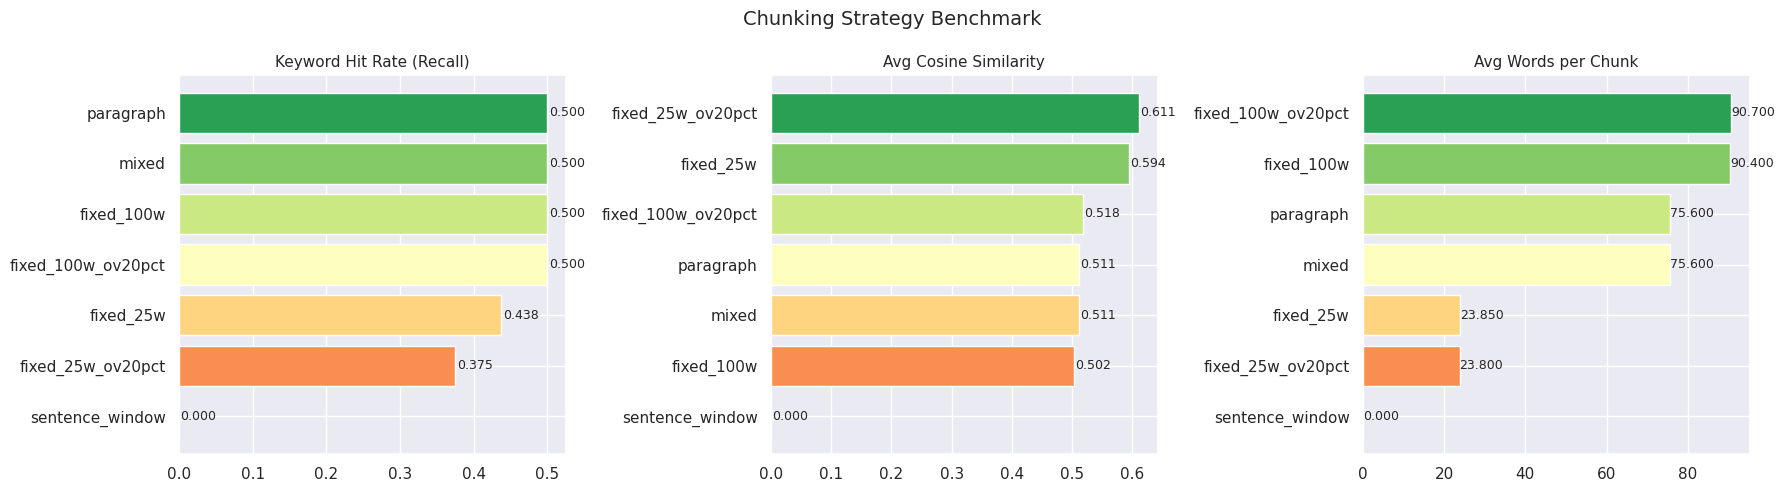

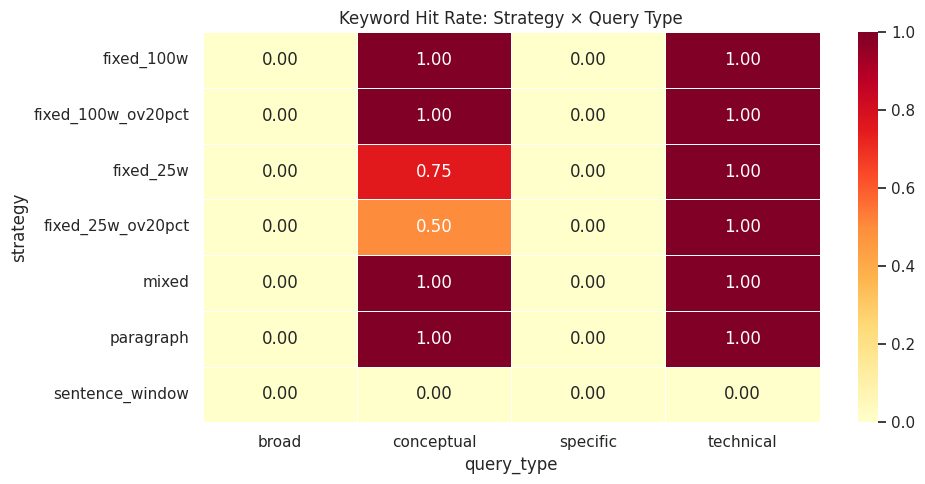

Best overall strategy: fixed_100w

Best for broad       : fixed_100w

Best for conceptual  : fixed_100w

Best for specific    : fixed_100w

Best for technical   : fixed_100w

In [15]:
# ─── Benchmark visualisations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Chunking Strategy Benchmark", fontsize=14)

for ax, (metric, title) in zip(axes, [
    ("hit_rate",  "Keyword Hit Rate (Recall)"),
    ("avg_score", "Avg Cosine Similarity"),
    ("avg_wc",    "Avg Words per Chunk"),
]):
    agg = bench_df.groupby("strategy")[metric].mean().sort_values()
    colors = sns.color_palette("RdYlGn", len(agg))
    bars = ax.barh(agg.index, agg.values, color=colors)
    ax.set_title(title, fontsize=11)
    for bar, val in zip(bars, agg.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Heatmap: hit_rate per strategy × query type
pivot = bench_df.pivot_table(values="hit_rate", index="strategy",
                              columns="query_type", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Keyword Hit Rate: Strategy × Query Type", fontsize=12)
plt.tight_layout()
plt.savefig("/content/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

best = pivot.mean(axis=1).idxmax()
console.print(f"\n[bold green]Best overall strategy: {best}[/bold green]")
for col in pivot.columns:
    console.print(f"  Best for [cyan]{col:12s}[/cyan]: {pivot[col].idxmax()}")

## CELL 15 — Interactive Demo

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15 — INTERACTIVE MULTI-STRATEGY COMPARISON
# Change YOUR_QUESTION and run!
# ═══════════════════════════════════════════════════════════════════════════════
from rich.panel import Panel
from rich.markdown import Markdown
from rich.table import Table

# ✏️  Change this to any question about Git
YOUR_QUESTION = "How does Git handle data integrity?"
COMPARE_STRATEGIES = ["fixed_25w_ov20pct", "fixed_100w_ov20pct", "paragraph", "mixed"]

console.rule(f"[bold yellow]🔍  {YOUR_QUESTION}")

summary_rows = []
for strat in COMPARE_STRATEGIES:
    chunks = retriever.retrieve(YOUR_QUESTION, strategy=strat, top_k=4, use_mmr=True)

    t0  = time.perf_counter()
    gen = generator.generate(YOUR_QUESTION, chunks)
    gen_ms = int((time.perf_counter() - t0) * 1000)

    console.print(Panel(
        Markdown(gen["answer"]),
        title=f"[bold cyan]{strat}[/bold cyan]  "
              f"[dim]{len(chunks)} chunks | {gen['input_tokens']}→{gen['output_tokens']} tok | {gen_ms}ms[/dim]",
        border_style="blue",
    ))

    summary_rows.append({
        "Strategy"  : strat,
        "Chunks"    : len(chunks),
        "Input tok" : gen["input_tokens"],
        "Output tok": gen["output_tokens"],
        "Gen ms"    : gen_ms,
    })

# Summary table
console.rule("[bold]Summary")
tbl = Table(show_lines=True)
for col in summary_rows[0]:
    tbl.add_column(col, style="cyan" if col == "Strategy" else "")
for row in summary_rows:
    tbl.add_row(*[str(row[c]) for c in row])
console.print(tbl)

───────────────────────────────────── 🔍  How does Git handle data integrity? ─────────────────────────────────────

╭────────────────────────────── fixed_25w_ov20pct  4 chunks | 338→136 tok | 6124ms ───────────────────────────────╮
│                                                                                                                 │
│  • Git can detect lost information in transit or file corruption. [1]                                           │
│  • The mechanism Git uses for this detection, referred to as checksumming, is a SHA-1 hash. [2]                 │
│  • A SHA-1 hash is a 40-character string made up of hexadecimal characters (0–9 and a–f). [2]                   │
│  • Operations in Git only add data to its database, making it difficult to perform actions that are not         │
│    undoable. [3]                                                                                                │
│                                                                                                                 │
│ Git handles data integrity by using SHA-1 checksums to detect corruption and by ensuring that all data          │
│ operations are additive, contributing to an undoable history.                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── fixed_100w_ov20pct  4 chunks | 638→228 tok | 7155ms ──────────────────────────────╮
│                                                                                                                 │
│  • Everything in Git is checksummed before it is stored and is then referred to by that checksum. [1]           │
│  • This mechanism makes it impossible to change the contents of any file or directory without Git detecting it. │
│    [1]                                                                                                          │
│  • This functionality is built into Git at its lowest levels and is integral to its philosophy. [1]             │
│  • Git can detect information loss in transit or file corruption. [1]                                           │
│  • The specific mechanism Git uses for checksumming is called a SHA-1 hash, which is a 40-character string. [1] │
│  • Nearly all actions in Git only add data to the Git database, making it difficult to perform undoable actions │
│    or erase data. [2]                                                                                           │
│  • Once a snapshot is committed into Git, it is very difficult to lose, especially if the database is regularly │
│    pushed to another repository. [2]                                                                            │
│                                                                                                                 │
│ Git handles data integrity by checksumming all stored data using SHA-1 hashes, which allows it to detect any    │
│ changes or corruption, and by primarily adding data to its database, making committed information very          │
│ difficult to lose.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── paragraph  4 chunks | 537→157 tok | 3860ms ───────────────────────────────────╮
│ Git handles data integrity through the following mechanisms:                                                    │
│                                                                                                                 │
│  • Everything in Git is checksummed before it is stored. [1]                                                    │
│  • Data is then referred to by that checksum. [1]                                                               │
│  • This makes it impossible to change the contents of any file or directory without Git detecting it. [1]       │
│  • This functionality is built into Git at its lowest levels. [1]                                               │
│  • Git can detect information loss in transit or file corruption. [1]                                           │
│  • Git stores everything in its database by the hash value of its contents, rather than by file name. [3]       │
│                                                                                                                 │
│ In summary, Git ensures data integrity by checksumming all stored content and referring to it by these          │
│ checksums, making any unauthorized changes or corruption immediately detectable.                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────── mixed  4 chunks | 537→137 tok | 5217ms ─────────────────────────────────────╮
│ Git handles data integrity through the following mechanisms:                                                    │
│                                                                                                                 │
│  • Everything in Git is checksummed before it is stored. [1]                                                    │
│  • Data is then referred to by that checksum. [1]                                                               │
│  • This makes it impossible to change the contents of any file or directory without Git detecting it. [1]       │
│  • Git can detect information loss in transit or file corruption. [1]                                           │
│  • Git stores everything in its database by the hash value of its contents, rather than by file name. [3]       │
│                                                                                                                 │
│ Git ensures data integrity by checksumming all stored content and using these checksums as references, allowing │
│ it to detect any unauthorized changes or corruption.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

───────────────────────────────────────────────────── Summary ─────────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┓
┃ Strategy           ┃ Chunks ┃ Input tok ┃ Output tok ┃ Gen ms ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━┩
│ fixed_25w_ov20pct  │ 4      │ 338       │ 136        │ 6124   │
├────────────────────┼────────┼───────────┼────────────┼────────┤
│ fixed_100w_ov20pct │ 4      │ 638       │ 228        │ 7155   │
├────────────────────┼────────┼───────────┼────────────┼────────┤
│ paragraph          │ 4      │ 537       │ 157        │ 3860   │
├────────────────────┼────────┼───────────┼────────────┼────────┤
│ mixed              │ 4      │ 537       │ 137        │ 5217   │
└────────────────────┴────────┴───────────┴────────────┴────────┘

---
## 📝 Key Takeaways

| Strategy | Best For | Notes |
|---|---|---|
| `fixed_25w` | Pinpoint factual lookups | Short, loses cross-boundary context |
| `fixed_100w` | Balanced factual retrieval | May split semantic units |
| `fixed_*_ov20pct` | Reduces boundary misses | ~25% more storage & compute |
| `paragraph` | Coherent conceptual answers | Variable sizes; very long paras hurt |
| `sentence_window` | Fine-grained with context | High chunk count |
| **`mixed` ✅** | **Production default** | **Best precision + context balance** |

